In [75]:
# Importing Modules

import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

In [76]:
data = pd.read_csv("train.csv")

In [77]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Since we are planning on performing Linear Regression, let's find the distribution of our target:

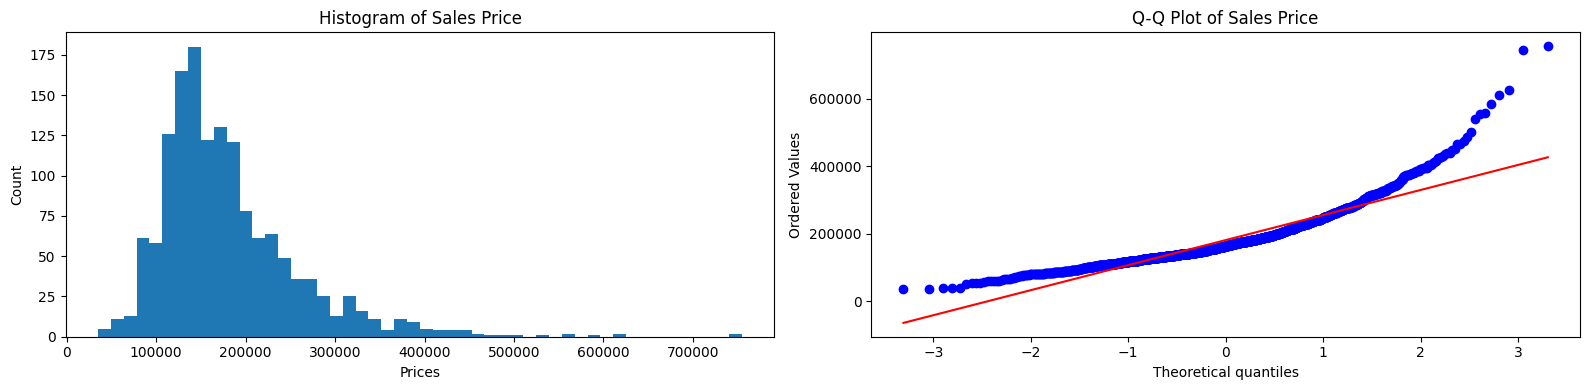

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(data["SalePrice"], bins=50)
axes[0].set_xlabel("Prices")
axes[0].set_ylabel("Count")
axes[0].set_title("Histogram of Sales Price")

stats.probplot(data["SalePrice"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Sales Price")

plt.tight_layout()
plt.show()

In [79]:
data["SalePrice"] = np.log(data["SalePrice"])

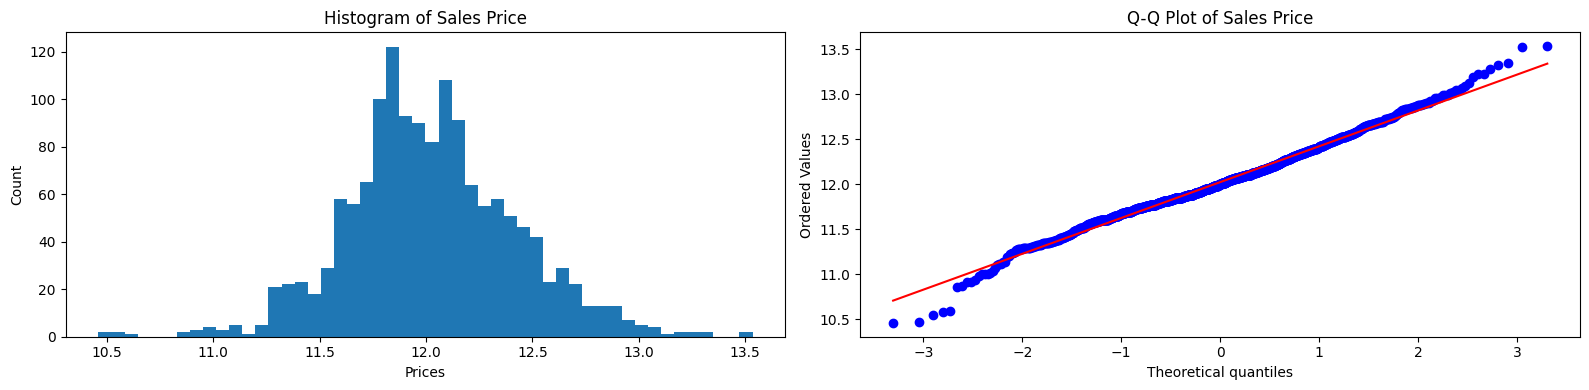

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(data["SalePrice"], bins=50)
axes[0].set_xlabel("Prices")
axes[0].set_ylabel("Count")
axes[0].set_title("Histogram of Sales Price")

stats.probplot(data["SalePrice"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Sales Price")

plt.tight_layout()
plt.show()

In [81]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Handling NAN entries:

In [82]:
data.select_dtypes(include=["int64", "float64"]).isna().sum().sort_values(ascending=False)

LotFrontage      259
GarageYrBlt       81
MasVnrArea         8
LotArea            0
MSSubClass         0
Id                 0
OverallCond        0
OverallQual        0
YearRemodAdd       0
YearBuilt          0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
BsmtFinSF1         0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
1stFlrSF           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
SalePrice          0
dtype: int64

In [83]:
# For normalization later:
norm_cols = data.select_dtypes(include="number").columns.tolist()
norm_cols = [col for col in norm_cols if col not in ["Id", "SalePrice"]]

In [84]:
zero_fill_cols = ["GarageYrBlt", "MasVnrArea", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "BsmtFinSF1", "2ndFlrSF", "LowQualFinSF", "BsmtFullBath", "BsmtHalfBath", "Fireplaces", "GarageCars", 
                  "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal"]

median_fill_cols = ["LotFrontage", "LotArea", "MSSubClass", "OverallCond", "OverallQual", "YearRemodAdd", "YearBuilt", "GrLivArea", "FullBath", "HalfBath", "1stFlrSF", "BedroomAbvGr", 
                    "KitchenAbvGr", "TotRmsAbvGrd", "MoSold", "YrSold"]

data[zero_fill_cols] = data[zero_fill_cols].fillna(0)

data[median_fill_cols] = data[median_fill_cols].fillna(data[median_fill_cols].median())

# For the other categorical columns, fill with "None".
data = data.fillna("None")

Creating Categorical Variables

In [85]:
obj_cols = data.select_dtypes(include="object").columns.to_numpy()
print(obj_cols)

['MSZoning' 'Street' 'Alley' 'LotShape' 'LandContour' 'Utilities'
 'LotConfig' 'LandSlope' 'Neighborhood' 'Condition1' 'Condition2'
 'BldgType' 'HouseStyle' 'RoofStyle' 'RoofMatl' 'Exterior1st'
 'Exterior2nd' 'MasVnrType' 'ExterQual' 'ExterCond' 'Foundation'
 'BsmtQual' 'BsmtCond' 'BsmtExposure' 'BsmtFinType1' 'BsmtFinType2'
 'Heating' 'HeatingQC' 'CentralAir' 'Electrical' 'KitchenQual'
 'Functional' 'FireplaceQu' 'GarageType' 'GarageFinish' 'GarageQual'
 'GarageCond' 'PavedDrive' 'PoolQC' 'Fence' 'MiscFeature' 'SaleType'
 'SaleCondition']


In [86]:
# Function to create categorical variables for columns with multiple categories.
def create_categorical_variables(data: pd.DataFrame, col: str, categories: list[str]) -> None:

    print(f"\n Creating Categorical Variables for column {col}:")

    # Create a categorical variable for each category.
    for category in categories:
        new_col = col + "-" + category
        data[new_col] = data[col].apply(lambda x: 1 if category in str(x) else 0)
        
        print(f" Created: {new_col}")

    # Drop the original column.
    data.drop(col, axis=1, inplace=True)

In [87]:
for col in obj_cols:
    categories = list(data[col].dropna().unique())

    if "None" not in categories:
        categories.append("None")

    create_categorical_variables(data, col, categories)


 Creating Categorical Variables for column MSZoning:
 Created: MSZoning-RL
 Created: MSZoning-RM
 Created: MSZoning-C (all)
 Created: MSZoning-FV
 Created: MSZoning-RH
 Created: MSZoning-None

 Creating Categorical Variables for column Street:
 Created: Street-Pave
 Created: Street-Grvl
 Created: Street-None

 Creating Categorical Variables for column Alley:
 Created: Alley-None
 Created: Alley-Grvl
 Created: Alley-Pave

 Creating Categorical Variables for column LotShape:
 Created: LotShape-Reg
 Created: LotShape-IR1
 Created: LotShape-IR2
 Created: LotShape-IR3
 Created: LotShape-None

 Creating Categorical Variables for column LandContour:
 Created: LandContour-Lvl
 Created: LandContour-Bnk
 Created: LandContour-Low
 Created: LandContour-HLS
 Created: LandContour-None

 Creating Categorical Variables for column Utilities:
 Created: Utilities-AllPub
 Created: Utilities-NoSeWa
 Created: Utilities-None

 Creating Categorical Variables for column LotConfig:
 Created: LotConfig-Inside
 

Linear Regression Training:

In [88]:
# Create data matrix and test vector.
X = data.drop(columns=["Id", "SalePrice"])
t = data["SalePrice"]

# Split into training and validation sets: (85% Training, 15% validation)
X_train, X_valid, t_train, t_valid = train_test_split(X, t, test_size=0.15, random_state=42)

In [89]:
mean = X_train[norm_cols].mean()
std = X_train[norm_cols].std()

X_train[norm_cols] = (X_train[norm_cols] - mean) / std
X_valid[norm_cols] = (X_valid[norm_cols] - mean) / std

In [90]:
stats_df = pd.DataFrame({
    "feature": mean.index,
    "mean": mean.values,
    "std": std.values
})

stats_df.to_csv("norm_stats.csv", index=False)

In [91]:
# Convert to numpy
X_train = X_train.values
X_valid = X_valid.values

# Add bias column
b_train = np.ones((X_train.shape[0], 1))
b_valid = np.ones((X_valid.shape[0], 1))

X_train = np.concatenate([X_train, b_train], axis=1)
X_valid = np.concatenate([X_valid, b_valid], axis=1)

In [92]:
def predict(w, X):
    """
    Compute prediction given data matrix X, and weight vector w. Let N be the number of data points, 
    and D be the number of features:

    Parameters:
        X - Data matrix of shape (N, D+1)
        w - weight vector of shape (D+1)
    
    Returns prediction vector of shape: (N)
    """
    return np.dot(X, w)

def mse(w, X, t):
    """
    Compute the mean squared error with the data matrix X, weight vector w and target vector t.

    Parameters:
        X - Data matrix of shape (N, D+1)
        w - weight vector of shape (D+1)
        t - target vector of shape (N)
    
    Returns a scalar value.
    """
    y = predict(w, X) # Get Predictions
    error = y - t # Calculate the error for all data points.
    return np.mean(error ** 2) # Compute total MSE value.

def grad(w, X, t):
    """
    Calculate the gradient vector of the cost function in respect to the weights. The cost function
    is what we computed in the mse function.

    Parameters:
        X - Data matrix of shape (N, D+1)
        w - weight vector of shape (D+1)
        t - target vector of shape (N)

    Returns the gradient vector of shape (D+1). Each row j is a summation of the difference between
    each data point's prediction and ground truth times each data point's respective jth feature. Each row
    then divides that value by the number of data points.
    """
    y = predict(w, X) # Get Predictions
    n = X.shape[0] # Get number of data points.
    error = y - t # Calculate the error for all data points.
    return (1/n) * np.dot(X.T, error) 


SKLearn

In [93]:
lr = LinearRegression(fit_intercept=False)
lr.fit(X_train, t_train)

print("Training MSE:", mse(lr.coef_ , X_train, t_train))
print("Validation MSE:", mse(lr.coef_ , X_valid, t_valid))

Training MSE: 0.00871152469809926
Validation MSE: 0.018346380890083842


Gradient Descent

In [94]:
def gradient_descent(alpha, n_iter, plot: bool, X_train=X_train, t_train=t_train, X_valid=X_valid, t_valid=t_valid):
    '''
    Performs gradient descent with a specific learning rate and fixed number of iterations to find the optimal
    weights that gives us the lowest mean squared error.

    Parameters:
        alpha - the learning rate
        n_iter - the number of iterations of gradient descent to run
        X_train - the data matrix to use for training
        t_train - the target vector to use for training
        X_valid - the data matrix to use for validation
        t_valid - the target vector to use for validation
        w_init - the initial `w` vector (if `None`, use a vector of all zeros)

    Returns the weight vector that produced the lowest training and validation mse. 
    '''
    # initialize all the weights to zeros
    w = np.zeros(X_train.shape[1])
    
    # we will track the MSE value at each iteration to record progress
    train_mses = []
    valid_mses = []

    for it in range(n_iter):

        # Calculate gradient vector, and update weights using learning rate. 
        gradient_descent = grad(w, X_train, t_train)
        w -= alpha * gradient_descent

        # Add the MSEs, so we can keep track of progress. 
        train_mses.append(mse(w, X_train, t_train))
        valid_mses.append(mse(w, X_valid, t_valid))

    # Plot the progression of the MSEs. 
    if plot:
        plt.title("Training Curve Showing Training and Validation MSE at each Iteration")
        plt.plot(train_mses, label="Training MSE")
        plt.plot(valid_mses, label="Validation MSE")
        plt.xlabel("Iterations")
        plt.ylabel("MSE")
        plt.legend()
        plt.show()

    print("Final Training MSE:", train_mses[-1])
    print("Final Validation MSE:", valid_mses[-1])

    return w

In [95]:
# First find the optimal learning rate using an arbitrary number of iterations:
learning_rates = [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1]
for alpha in learning_rates:
    print(f"\nTesting for alpha rate: {alpha}")
    gradient_descent(alpha=alpha, n_iter=1000, plot=False)


Testing for alpha rate: 1e-06
Final Training MSE: 136.69202894212194
Final Validation MSE: 136.15172185788833

Testing for alpha rate: 1e-05
Final Training MSE: 81.36106498408391
Final Validation MSE: 80.78090805724193

Testing for alpha rate: 0.0001
Final Training MSE: 1.033666260806743
Final Validation MSE: 0.9156213224268185

Testing for alpha rate: 0.001
Final Training MSE: 0.2842071010102878
Final Validation MSE: 0.28519560507931885

Testing for alpha rate: 0.01
Final Training MSE: 0.0728963379009859
Final Validation MSE: 0.08054144625798254

Testing for alpha rate: 0.1
Final Training MSE: inf
Final Validation MSE: inf


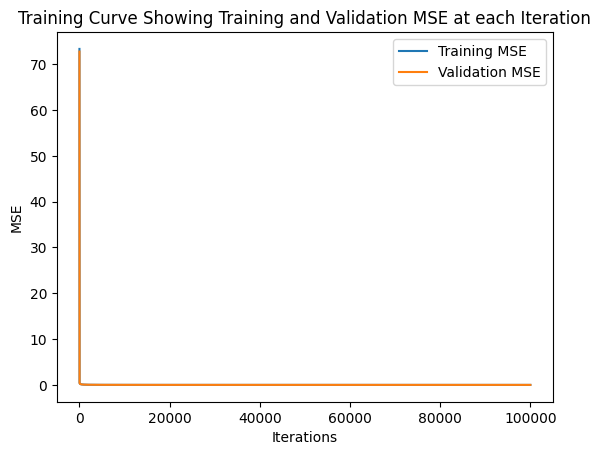

Final Training MSE: 0.00970926163612599
Final Validation MSE: 0.016399157785581663


In [96]:
w = gradient_descent(alpha=0.01, n_iter=100000, plot=True)

In [97]:
np.save("weights.npy", w)